<a href="https://colab.research.google.com/github/kyungeunvoyage/NailFoldExp/blob/main/Analysis/(Analysis)Force_Discrimination.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 스타일 설정
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

#x 축에 페어가 오는 전체 코드 (isCorrect 재배열)



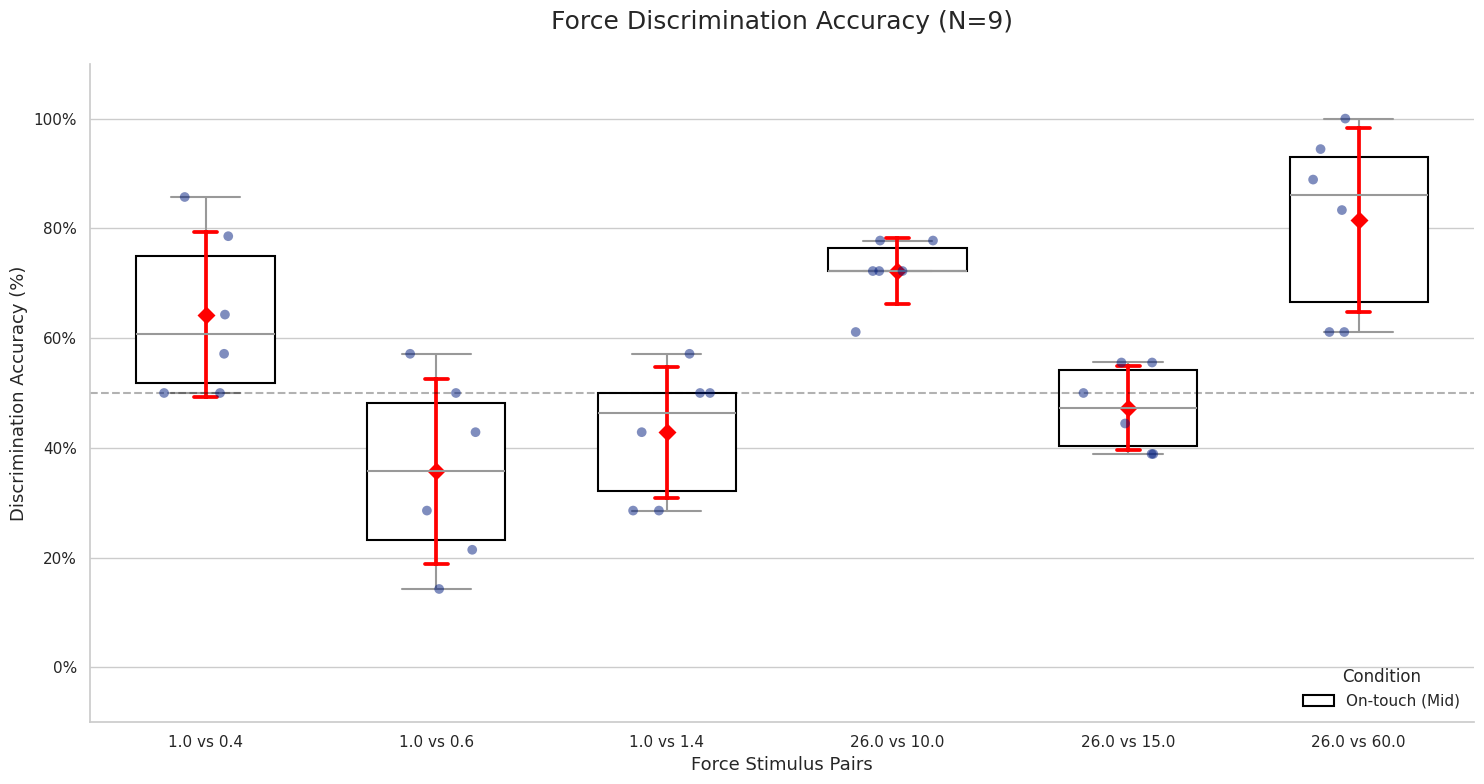

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import glob

# 1. 데이터 로드 및 통합
file_pattern = 'P*_ForceDiscrimination.csv'
file_list = glob.glob(file_pattern)

if not file_list:
    print("CSV 파일을 찾을 수 없습니다.")
else:
    df_list = [pd.read_csv(f) for f in file_list]
    df_merged = pd.concat(df_list, ignore_index=True)

    # 2. 전처리 및 정답 로직
    df_merged['Ref_num'] = pd.to_numeric(df_merged['Reference'])
    df_merged['Comp_num'] = pd.to_numeric(df_merged['Comparison'])
    df_merged['Pair'] = df_merged.apply(lambda x: f"{x['Ref_num']:.1f} vs {x['Comp_num']:.1f}", axis=1)

    def calc_accuracy(row):
        if row['FirstStim'] > row['SecondStim']:
            return 1 if row['UserChoice'] == 1 else 0
        elif row['SecondStim'] > row['FirstStim']:
            return 1 if row['UserChoice'] == 2 else 0
        else:
            return 0.5

    df_merged['IsCorrect'] = df_merged.apply(calc_accuracy, axis=1)

    # 3. 분석 그룹화
    plot_df = df_merged.groupby(['Condition', 'Pair', 'Comp_num', 'Region'])['IsCorrect'].mean().reset_index()
    plot_df['Accuracy (%)'] = plot_df['IsCorrect'] * 100
    pair_order = plot_df.sort_values('Comp_num')['Pair'].unique()

    # --- [중요] 조건 개수에 따른 dodge 및 palette 설정 ---
    unique_conditions = plot_df['Condition'].unique()
    num_cond = len(unique_conditions)

    # 조건이 1개면 dodge를 False(0)로, 2개 이상이면 0.5로 설정
    dodge_val = 0.5 if num_cond > 1 else False
    # 조건 개수에 맞게 팔레트 색상 개수 조절 (경고 방지)
    base_palette = ['#FFFFFF', '#D3D3D3'][:num_cond]

    # 4. 시각화
    plt.figure(figsize=(15, 8))
    sns.set_theme(style="whitegrid")

    # [A] 박스플롯
    sns.boxplot(
        data=plot_df,
        x='Pair',
        y='Accuracy (%)',
        hue='Condition',
        order=pair_order,
        palette=base_palette,
        width=0.6,
        linewidth=1.5,
        fliersize=0,
        boxprops={'edgecolor': 'black'}
    )

    # [B] 스트립플롯 (dodge_val 적용)
    sns.stripplot(
        data=plot_df,
        x='Pair',
        y='Accuracy (%)',
        hue='Condition',
        order=pair_order,
        dodge=dodge_val,
        palette='dark',
        size=7,
        alpha=0.5,
        jitter=0.2
    )

    # [C] 에러바 (dodge_val 적용 및 FutureWarning 방지용 palette 사용)
    sns.pointplot(
        data=plot_df,
        x='Pair',
        y='Accuracy (%)',
        hue='Condition',
        order=pair_order,
        dodge=dodge_val,
        palette=['red'] * num_cond, # color='red' 대신 palette 사용
        errorbar='sd',
        markers='D',
        linestyle='none',
        capsize=.1
    )

    # 그래프 레이아웃 설정
    num_subjects = df_merged['Subject'].nunique()
    plt.title(f'Force Discrimination Accuracy (N={num_subjects})', fontsize=18, pad=25)
    plt.ylabel('Discrimination Accuracy (%)', fontsize=13)
    plt.xlabel('Force Stimulus Pairs', fontsize=13)

    plt.axhline(50, ls='--', color='black', alpha=0.3, label='Chance (50%)')
    plt.ylim(-10, 110)
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())

    # 범례 설정 (조건 개수만큼만 표시)
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles[:num_cond], labels[:num_cond], title='Condition', frameon=False, loc='lower right')

    sns.despine()
    plt.tight_layout()
    plt.show()

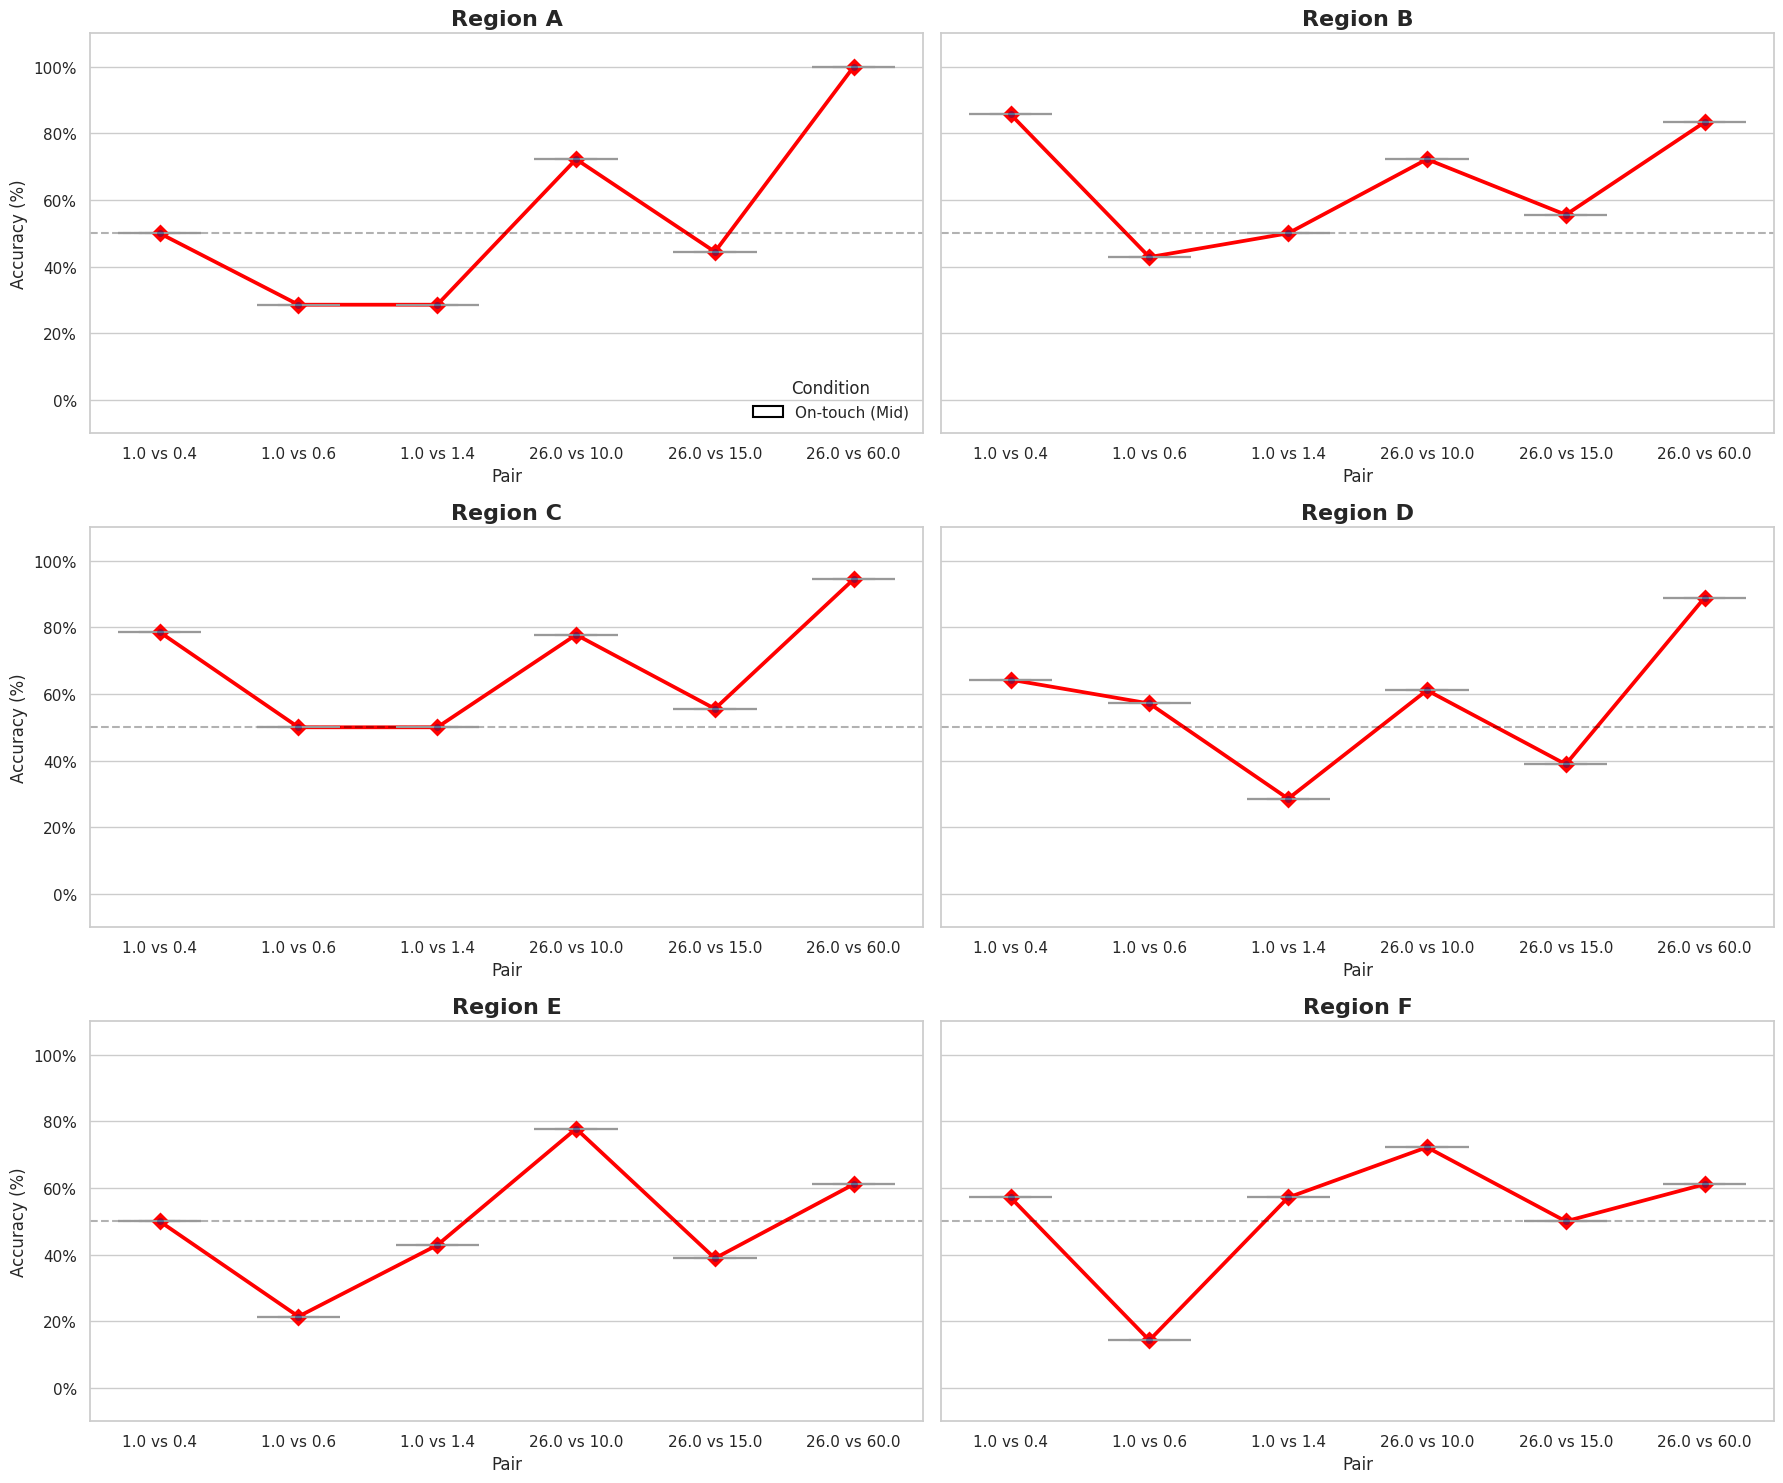


 [구역별(Region) x 조건별(Condition) 평균 정답률 (%)] 
Condition  On-touch (Mid)
Region                   
A               53.968254
B               64.947090
C               67.724868
D               56.481481
E               48.677249
F               51.984127


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import glob

# 1. 데이터 로드 및 통합 (P*로 시작하는 모든 ForceDiscrimination 파일)
file_pattern = 'P*_ForceDiscrimination.csv'
file_list = glob.glob(file_pattern)

if not file_list:
    print("CSV 파일을 찾을 수 없습니다.")
else:
    df_list = [pd.read_csv(f) for f in file_list]
    df_merged = pd.concat(df_list, ignore_index=True)

    # 2. 전처리 및 정답(IsCorrect) 로직 반영
    df_merged['Ref_num'] = pd.to_numeric(df_merged['Reference'])
    df_merged['Comp_num'] = pd.to_numeric(df_merged['Comparison'])
    df_merged['Pair'] = df_merged.apply(lambda x: f"{x['Ref_num']:.1f} vs {x['Comp_num']:.1f}", axis=1)

    def calc_accuracy(row):
        # 더 강한 자극을 선택했는지 판별
        if row['FirstStim'] > row['SecondStim']:
            return 1 if row['UserChoice'] == 1 else 0
        elif row['SecondStim'] > row['FirstStim']:
            return 1 if row['UserChoice'] == 2 else 0
        else:
            return 0.5

    df_merged['IsCorrect'] = df_merged.apply(calc_accuracy, axis=1)

    # 3. 분석 그룹화 (Region 포함)
    plot_df = df_merged.groupby(['Condition', 'Pair', 'Comp_num', 'Region'])['IsCorrect'].mean().reset_index()
    plot_df['Accuracy (%)'] = plot_df['IsCorrect'] * 100
    pair_order = plot_df.sort_values('Comp_num')['Pair'].unique()
    regions = sorted(plot_df['Region'].unique())

    # 4. 시각화 (Region별 3x2 Subplots 생성)
    n_rows = (len(regions) + 1) // 2
    fig, axes = plt.subplots(n_rows, 2, figsize=(18, 5 * n_rows), sharey=True)
    axes = axes.flatten()
    sns.set_theme(style="whitegrid")

    for i, reg in enumerate(regions):
        reg_data = plot_df[plot_df['Region'] == reg]
        ax = axes[i]

        num_cond = reg_data['Condition'].nunique()
        # 조건이 1개일 때 ZeroDivisionError 방지를 위해 dodge_val 설정
        dodge_val = 0.4 if num_cond > 1 else False
        palette = ['#FFFFFF', '#D3D3D3'][:num_cond]

        # [A] 박스플롯 (분포 확인)
        sns.boxplot(
            ax=ax, data=reg_data, x='Pair', y='Accuracy (%)', hue='Condition',
            order=pair_order, palette=palette, width=0.6, linewidth=1.5,
            fliersize=0, boxprops={'edgecolor': 'black'}
        )

        # [B] 스트립플롯 (개별 데이터 점)
        sns.stripplot(
            ax=ax, data=reg_data, x='Pair', y='Accuracy (%)', hue='Condition',
            order=pair_order, dodge=dodge_val, palette='dark', size=5, alpha=0.4, jitter=0.2
        )

        # [C] 포인트플롯 (평균 추세선 연결)
        sns.pointplot(
            ax=ax, data=reg_data, x='Pair', y='Accuracy (%)', hue='Condition',
            order=pair_order, dodge=dodge_val, palette=['red']*num_cond,
            markers='D', linestyles='-', errorbar=None
        )

        ax.set_title(f'Region {reg}', fontsize=16, fontweight='bold')
        ax.axhline(50, ls='--', color='black', alpha=0.3) # 50% 기준선
        ax.set_ylim(-10, 110)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())

        # 범례 설정 (첫 번째 그래프에만 표시)
        if i == 0:
            handles, labels = ax.get_legend_handles_labels()
            ax.legend(handles[:num_cond], labels[:num_cond], title='Condition', frameon=False, loc='lower right')
        else:
            if ax.get_legend(): ax.get_legend().remove()

    # 데이터가 없는 빈 그래프 삭제
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

    # 5. 구역별 평균 정확도 요약표 출력
    print("\n" + "="*50)
    print(" [구역별(Region) x 조건별(Condition) 평균 정답률 (%)] ")
    print("="*50)
    summary = plot_df.groupby(['Region', 'Condition'])['Accuracy (%)'].mean().unstack()
    print(summary)